# ROUTER

## 数据

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # 只使用第0号GPU
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')
from torchvision.models.segmentation import deeplabv3_resnet50
import torch
import torch.nn.functional as F
import numpy as np
import requests
import torchvision
from PIL import Image

import sys
sys.path.append('/nas_data/LSH/OpenSTL-MOR')
from openstl.datasets.dataloader_human import load_data

dataloader_train, _, dataloader_test = \
        load_data(batch_size=8,
                  val_batch_size=4,
                  data_root='/nas_data/LSH/data/',
                  num_workers=4,
                  pre_seq_length=4, aft_seq_length=4,
                  use_prefetcher=True, distributed=False)

print(len(dataloader_train), len(dataloader_test))
batch_x, batch_y = None, None
for item in dataloader_train:
    print(item[0].shape, item[1].shape)
    batch_x = item[0]
    batch_y = item[1]
    break

input_tensor = batch_x.cuda()

9175 2146
torch.Size([8, 4, 3, 256, 256]) torch.Size([8, 4, 3, 256, 256])


## MOD

In [2]:
root_mod = '/nas_data/LSH/OpenSTL-MOR/work_dirs/human/predformer/TSSTattion_onecycle_dim256_head8_ndepth3_patch8_mod0_3'
from openstl.methods.ModPredFormer import PredFormer_method
ckpt = torch.load(root_mod + '/checkpoints/best.ckpt')
# print(ckpt.keys())
import json
# 读取 JSON 文件
with open(root_mod + "/model_param.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# print(config)
# print(ckpt['state_dict'].keys())
method = PredFormer_method(steps_per_epoch=len(dataloader_train),  test_mean=None, test_std=None, save_dir='.', **config)

method.load_state_dict(ckpt['state_dict'])
model_mod = method.model
model_mod.eval()
model_mod = model_mod.cuda()
output, router_logits_mod = model_mod(input_tensor)

## MOD + diff

In [3]:
root_mod = '/nas_data/LSH/OpenSTL-MOR/work_dirs/human/predformer/TSSTattion_onecycle_dim256_head8_ndepth3_patch8_mod0_3_routerloss'
from openstl.methods.ModPredFormer import PredFormer_method
ckpt = torch.load(root_mod + '/checkpoints/best.ckpt')
# print(ckpt.keys())
import json
# 读取 JSON 文件
with open(root_mod + "/model_param.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# print(config)
# print(ckpt['state_dict'].keys())
method = PredFormer_method(steps_per_epoch=len(dataloader_train),  test_mean=None, test_std=None, save_dir='.', **config)

method.load_state_dict(ckpt['state_dict'])
model_mod_diffloss = method.model
model_mod_diffloss.eval()
model_mod_diffloss = model_mod_diffloss.cuda()
output, router_logits_mod_diffloss = model_mod_diffloss(input_tensor)

## MOD + FLOW

In [4]:
root_mod = '/nas_data/LSH/OpenSTL-MOR/work_dirs/human/predformer/TSSTattion_onecycle_dim256_head8_ndepth3_patch8_mod0_3_routerloss_flow'
from openstl.methods.ModPredFormer import PredFormer_method
ckpt = torch.load(root_mod + '/checkpoints/best.ckpt')
# print(ckpt.keys())
import json
# 读取 JSON 文件
with open(root_mod + "/model_param.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# print(config)
# print(ckpt['state_dict'].keys())
method = PredFormer_method(steps_per_epoch=len(dataloader_train),  test_mean=None, test_std=None, save_dir='.', **config)

method.load_state_dict(ckpt['state_dict'])
model_mod_diffloss = method.model
model_mod_diffloss.eval()
model_mod_flowloss = model_mod_diffloss.cuda()
output, router_logits_mod_flowloss = model_mod_flowloss(input_tensor)

## 绘图

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

def visualize_router_spatial(router_tensor, frames=None, patch_size=8, normalize=True, save_path=None):
    """
    可视化 router logits 的空间分布（按时间帧显示）
    
    Args:
        router_tensor: torch.Tensor, shape [T, 1024] 或 [B, T, 1024]
        frames: torch.Tensor 或 np.ndarray, shape [T, 3, H, W] 或 [T, H, W, 3]，原始帧图像
        patch_size: 每个 patch 的边长（默认 8）
        normalize: 是否归一化到 [0,1]
        save_path: 可选，保存路径
    """
    router_tensor = F.softmax(router_tensor/0.2, dim=-1)  # 归一化
    # 取第一个样本
    if router_tensor.dim() == 3:
        router_tensor = router_tensor[0]  # [T, 1024]
    T, N = router_tensor.shape
    grid_size = int(np.sqrt(N))
    H, W = grid_size * patch_size, grid_size * patch_size

    # 转 numpy
    router_maps = router_tensor.detach().cpu().numpy().reshape(T, grid_size, grid_size)

    if normalize:
        router_maps = (router_maps - router_maps.min(axis=(1,2), keepdims=True)) / \
                      (router_maps.max(axis=(1,2), keepdims=True) - router_maps.min(axis=(1,2), keepdims=True) + 1e-8)

    # 上采样到原始尺寸
    up_maps = np.stack([cv2.resize(m, (W, H), interpolation=cv2.INTER_CUBIC) for m in router_maps])

    fig, axes = plt.subplots(1, T, figsize=(4*T, 4))
    if T == 1:
        axes = [axes]

    for i in range(T):
        ax = axes[i]

        if frames is not None:
            # 处理输入帧
            frame = frames[i]
            if torch.is_tensor(frame):
                frame = frame.permute(1, 2, 0).cpu().numpy()
            frame = (frame - frame.min()) / (frame.max() - frame.min() + 1e-8)
            overlay = 0.6 * frame + 0.4 * plt.cm.jet(up_maps[i])[:, :, :3]
            ax.imshow(overlay)
        else:
            ax.imshow(up_maps[i], cmap='hot')

        ax.set_title(f'Frame {i}', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

def visualize_router_topk(router_tensor, frames, patch_size=8, ratio=0.3, save_path=None):
    """
    可视化 router logits 的 top-k 激活区域并叠加在原图上
    Args:
        router_tensor: torch.Tensor, [T, 1024] 或 [B, T, 1024]
        frames: torch.Tensor 或 np.ndarray, [T, 3, H, W] 或 [T, H, W, 3]
        patch_size: 每个 patch 的边长（默认 8）
        ratio: top 区域比例 (0.3 = 前30%)
        save_path: 可选，保存路径
    """
    # 取 batch 0
    if router_tensor.dim() == 3:
        router_tensor = router_tensor[0]  # [T, 1024]
    T, N = router_tensor.shape
    grid = int(np.sqrt(N))
    H, W = grid * patch_size, grid * patch_size

    router_maps = router_tensor.detach().cpu().numpy().reshape(T, grid, grid)
    fig, axes = plt.subplots(1, T, figsize=(4*T, 4))

    if T == 1:
        axes = [axes]

    for i in range(T):
        # ====== Step 1: 计算 top 0.3 mask ======
        flat = router_maps[i].flatten()
        k = int(len(flat) * ratio)
        thresh = np.partition(flat, -k)[-k]  # 找出前 k 大的阈值
        mask = (router_maps[i] >= thresh).astype(np.float32)  # 1=高激活区域

        # ====== Step 2: 上采样到 256×256 ======
        mask_up = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)

        # ====== Step 3: 读取并归一化原图 ======
        frame = frames[i]
        if torch.is_tensor(frame):
            frame = frame.permute(1, 2, 0).cpu().numpy()
        frame = (frame - frame.min()) / (frame.max() - frame.min() + 1e-8)

        # ====== Step 4: 构造叠加图 ======
        color_mask = np.zeros_like(frame)
        color_mask[..., 0] = mask_up  # 红色通道标识激活区域
        overlay = (1 - 0.5 * mask_up[..., None]) * frame + 0.5 * color_mask

        ax = axes[i]
        ax.imshow(overlay)
        ax.set_title(f'Frame {i} | Top {int(ratio*100)}%', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


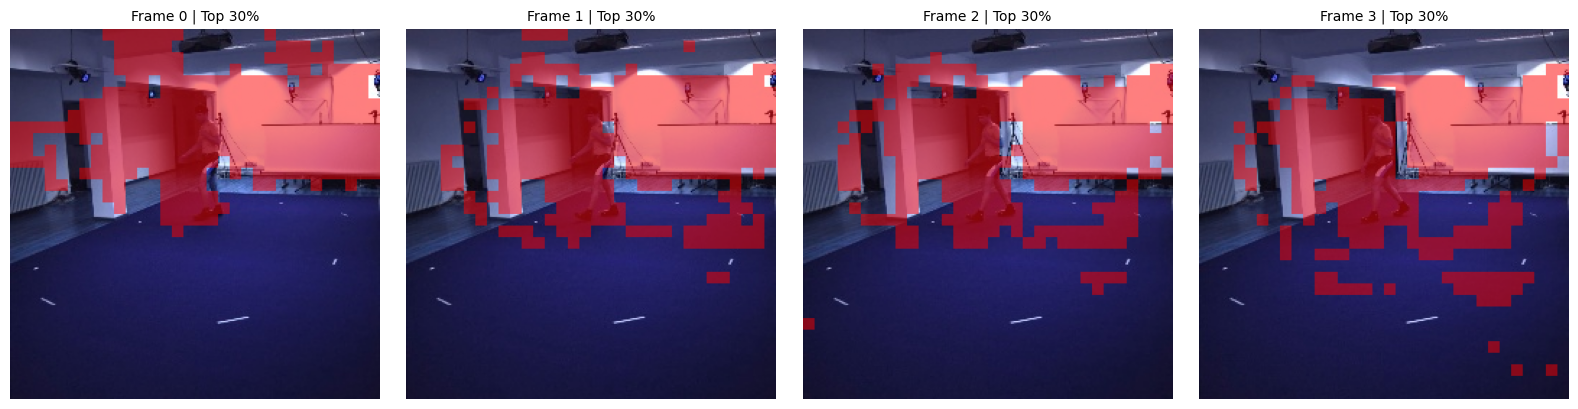

In [16]:
item = router_logits_mod[-1]  # 取第一个 block 的 router logits
b ,n, d = item.shape
item = item.reshape(-1, 4, n)
item = item.squeeze(-1)   # [B*T, N]
# 恢复成 [B, T, N]
item = item.view(-1, 4, n)
visualize_router_topk(item, frames=batch_x[0], patch_size=8)

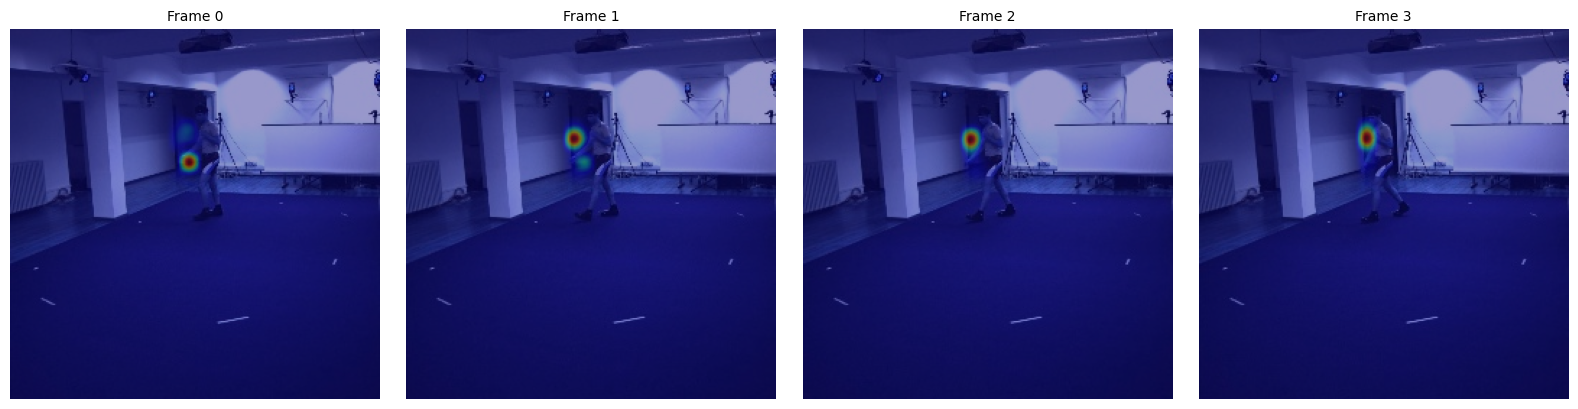

In [17]:
visualize_router_spatial(item, frames=batch_x[0], patch_size=8)

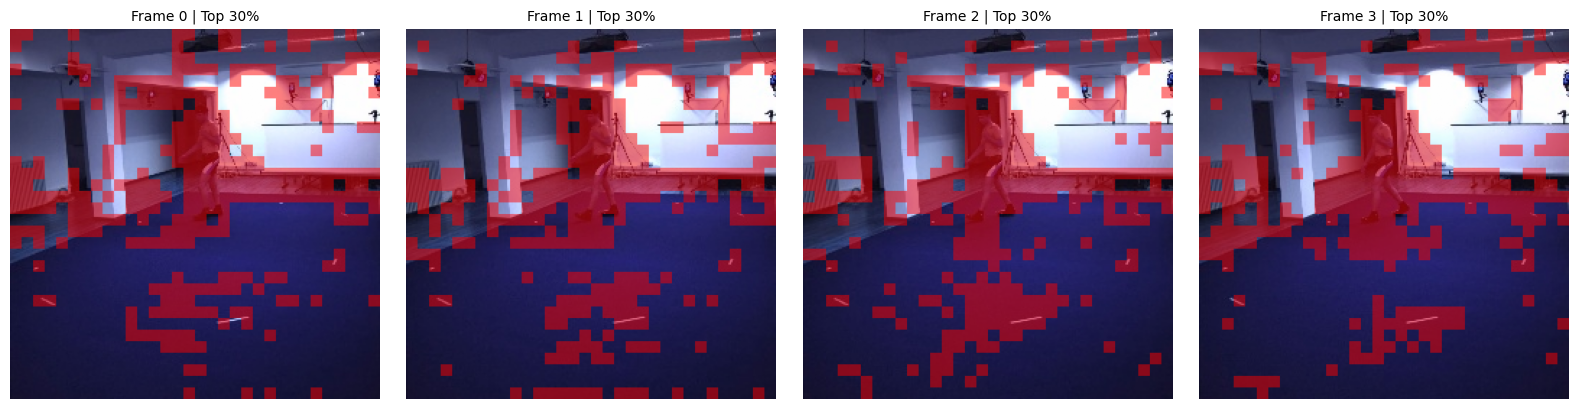

In [20]:
item = router_logits_mod_diffloss[-1]  # 取第一个 block 的 router logits
b ,n, d = item.shape
item = item.reshape(-1, 4, n)
item = item.squeeze(-1)   # [B*T, N]
# 恢复成 [B, T, N]
item = item.view(-1, 4, n)
visualize_router_topk(item, frames=batch_x[0], patch_size=8)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


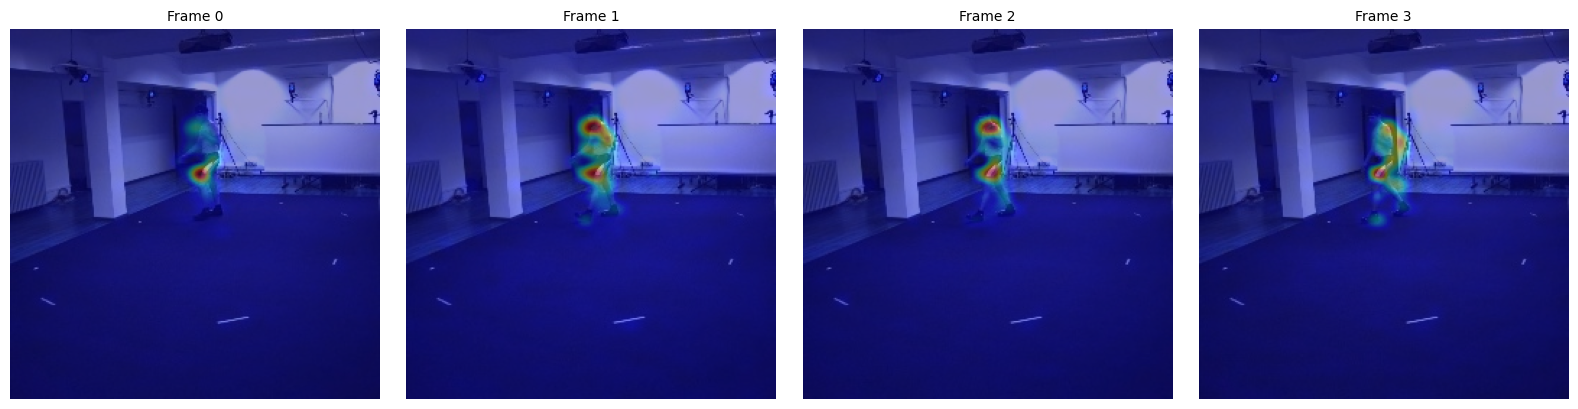

In [10]:
visualize_router_spatial(item, frames=batch_x[0], patch_size=8)

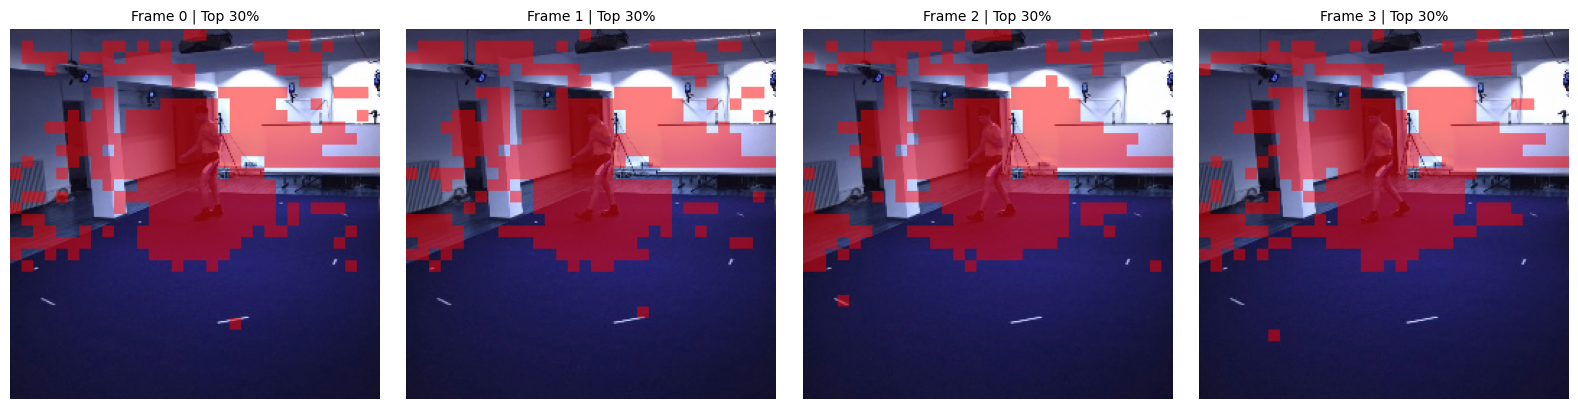

In [11]:
item = router_logits_mod_flowloss[0]  # 取第一个 block 的 router logits
b ,n, d = item.shape
item = item.reshape(-1, 4, n)
item = item.squeeze(-1)   # [B*T, N]
# 恢复成 [B, T, N]
item = item.view(-1, 4, n)
visualize_router_topk(item, frames=batch_x[0], patch_size=8)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000000238418578].


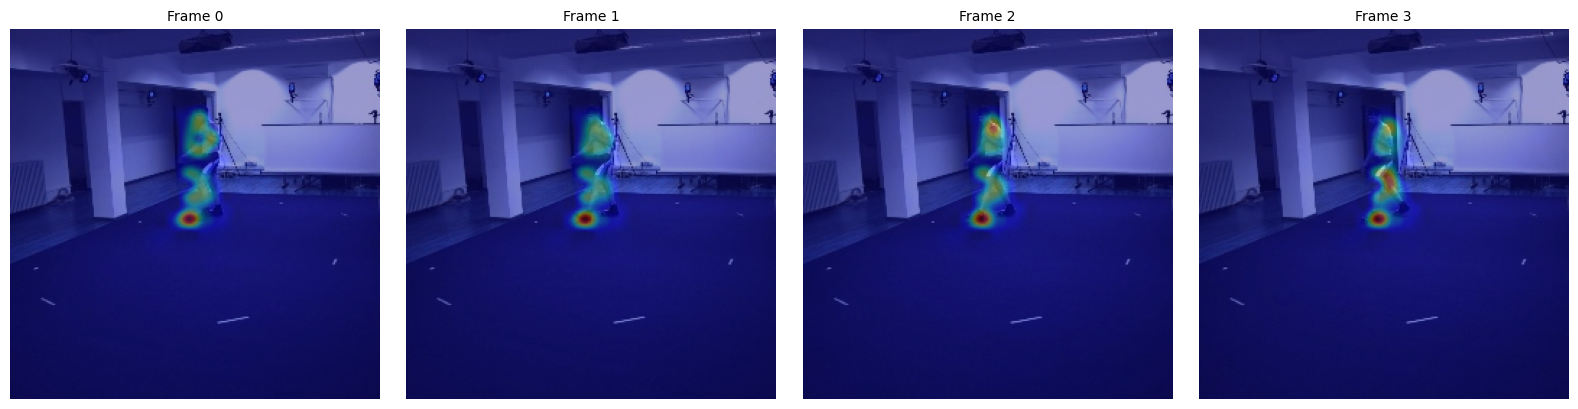

In [12]:
visualize_router_spatial(item, frames=batch_x[0], patch_size=8)